In [2]:
import sys
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

#noinspection PyUnresolvedReferences
from model import UNet
#noinspection PyUnresolvedReferences
from dataset import get_dataloader

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


In [4]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

class PerceptualLoss(nn.Module):
    def __init__(self, vgg_model):
        super().__init__()
        self.vgg = vgg_model
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        pred_norm = (pred + 1) / 2
        target_norm = (target + 1) / 2

        pred_features = self.vgg(pred_norm)
        target_features = self.vgg(target_norm)
        return self.mse(pred_features, target_features)

In [5]:
def show_prediction(model, gray_batch, color_batch, epoch):
    model.eval()
    with torch.no_grad():
        gray_batch = gray_batch.to(device)
        pred_batch = model(gray_batch)

        # Берем первое изображение из батча
        gray_img = gray_batch[0].cpu().squeeze().numpy()
        pred_img = pred_batch[0].cpu().permute(1, 2, 0).numpy()
        true_img = color_batch[0].cpu().permute(1, 2, 0).numpy()

        # Нормализация
        pred_img = np.clip(pred_img, 0, 1)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(gray_img, cmap='gray')
        axes[0].set_title("Вход (ч/б)")
        axes[0].axis('off')

        axes[1].imshow(pred_img)
        axes[1].set_title(f"Предсказание (эпоха {epoch})")
        axes[1].axis('off')

        axes[2].imshow(true_img)
        axes[2].set_title("Реальное цветное")
        axes[2].axis('off')

        plt.show()

    model.train()

In [7]:
data_dir = '../data/processed/test'
train_loader = get_dataloader(data_dir, batch_size=16, shuffle=True)

print(f"Загружено {len(train_loader.dataset)} изображений")
print(f"Батчей: {len(train_loader)}")

Загружено 2 изображений
Батчей: 1


In [8]:
vgg = models.vgg16(weights='DEFAULT').features.eval().to(device)

for param in vgg.parameters():
    param.requires_grad = False

In [9]:
model = UNet(in_channels=1, out_channels=3).to(device)

# Определяем функции потерь
criterion_mse = nn.MSELoss()
criterion_perceptual = PerceptualLoss(vgg)
lambda_perceptual = 0.1

# Оптимизатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Модель готова к обучению")

✅ Модель готова к обучению


Начинаем обучение...

✅ Эпоха 1 завершена | Средняя потеря: 0.3858
✅ Эпоха 2 завершена | Средняя потеря: 0.2878


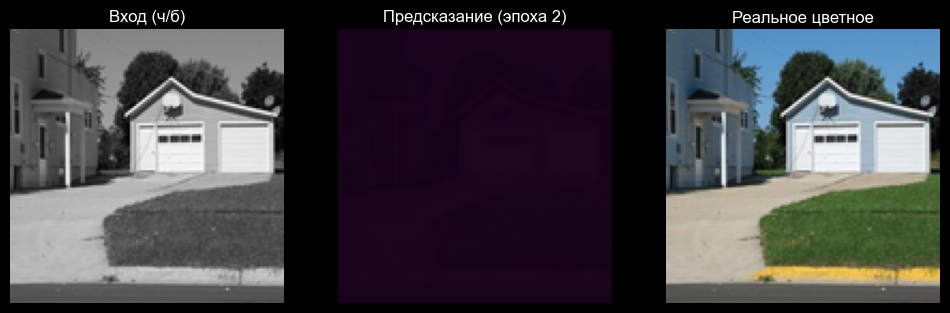

✅ Эпоха 3 завершена | Средняя потеря: 0.2104
✅ Эпоха 4 завершена | Средняя потеря: 0.1765


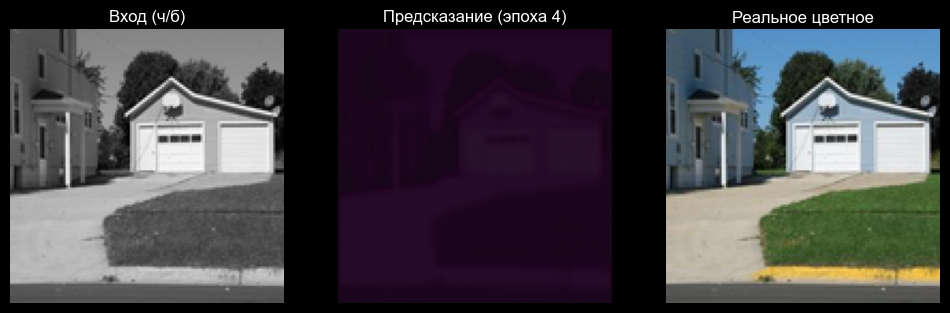

✅ Эпоха 5 завершена | Средняя потеря: 0.1313
✅ Эпоха 6 завершена | Средняя потеря: 0.1022


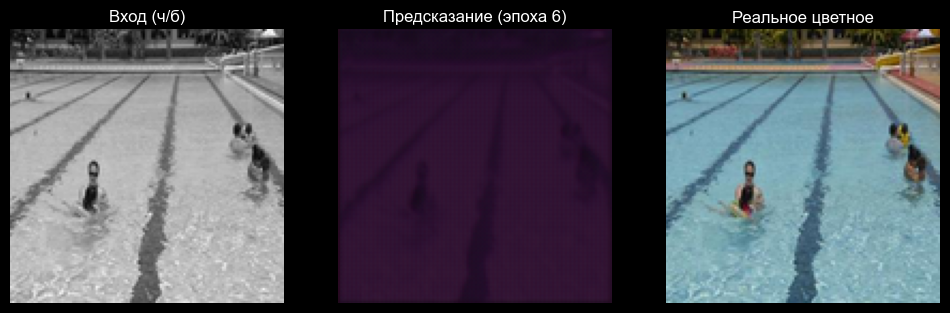

✅ Эпоха 7 завершена | Средняя потеря: 0.0756
✅ Эпоха 8 завершена | Средняя потеря: 0.0562


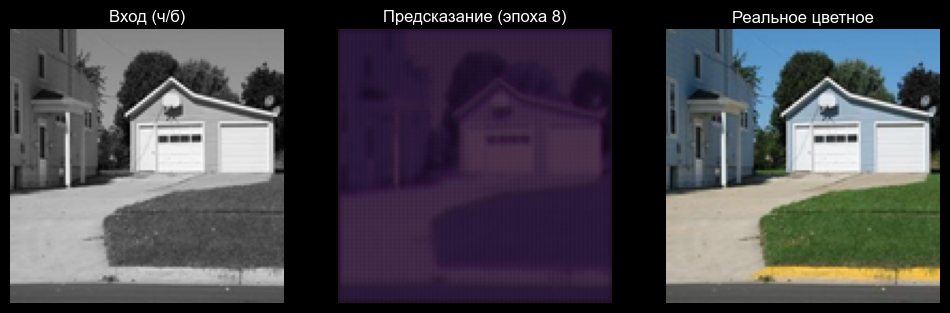

✅ Эпоха 9 завершена | Средняя потеря: 0.0431
✅ Эпоха 10 завершена | Средняя потеря: 0.0336


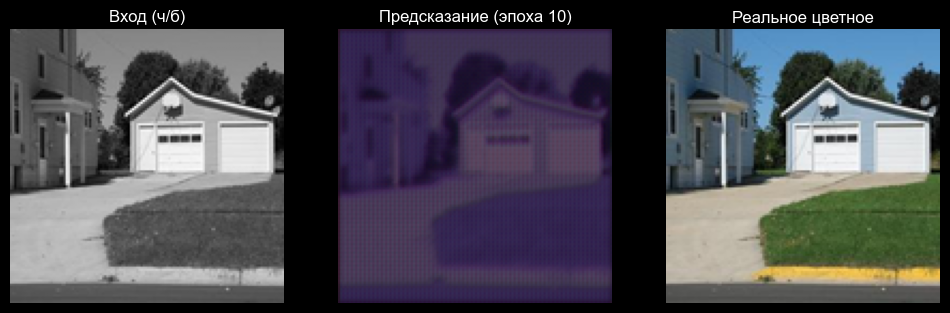

✅ Эпоха 11 завершена | Средняя потеря: 0.0269
✅ Эпоха 12 завершена | Средняя потеря: 0.0206


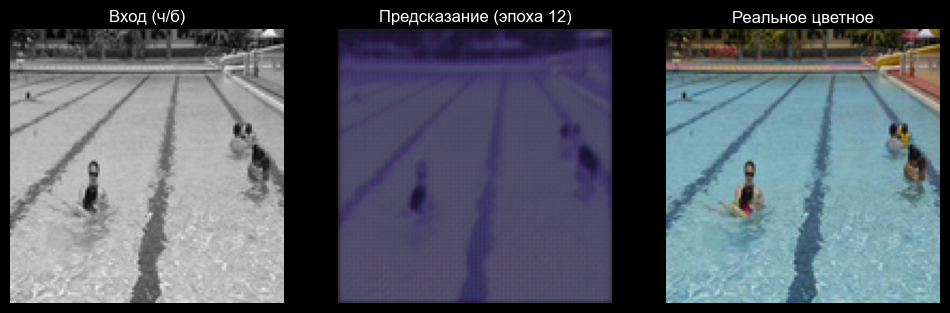

✅ Эпоха 13 завершена | Средняя потеря: 0.0178
✅ Эпоха 14 завершена | Средняя потеря: 0.0150


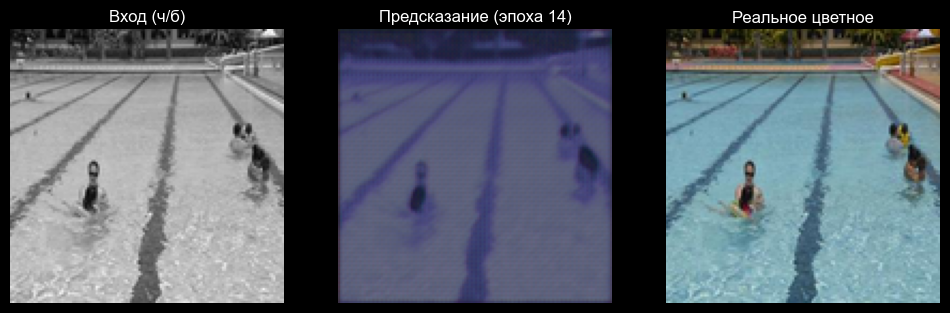

✅ Эпоха 15 завершена | Средняя потеря: 0.0149
✅ Эпоха 16 завершена | Средняя потеря: 0.0114


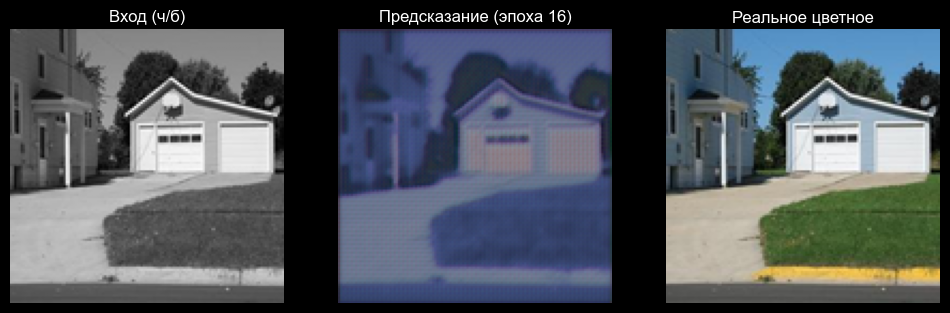

✅ Эпоха 17 завершена | Средняя потеря: 0.0104
✅ Эпоха 18 завершена | Средняя потеря: 0.0104


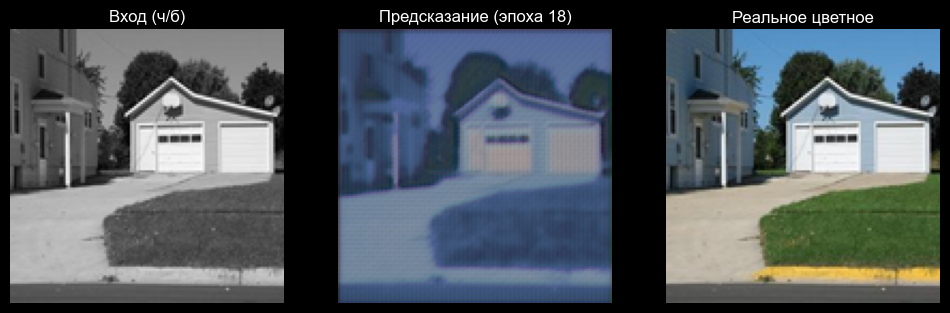

✅ Эпоха 19 завершена | Средняя потеря: 0.0089
✅ Эпоха 20 завершена | Средняя потеря: 0.0087


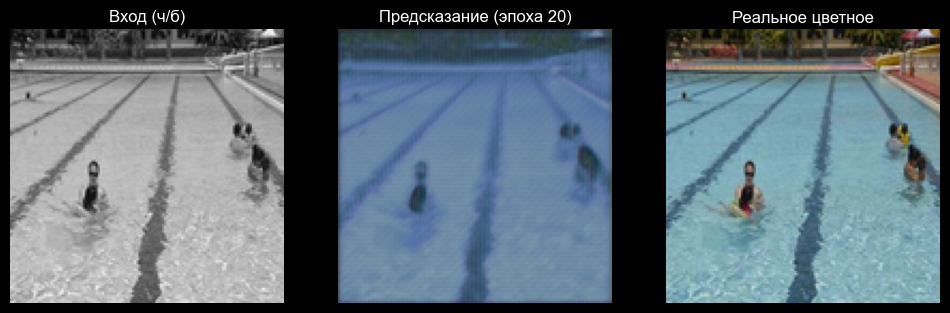

In [10]:
num_epochs = 20
train_losses = []

print("Начинаем обучение...\n")

for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch_idx, (gray_batch, color_batch) in enumerate(train_loader):
        # Перемещаем данные на GPU
        gray_batch = gray_batch.to(device)
        color_batch = color_batch.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(gray_batch)

        # Вычисляем комбинированную потерю
        mse_loss = criterion_mse(outputs, color_batch)
        perceptual_loss = criterion_perceptual(outputs, color_batch)
        loss = mse_loss + lambda_perceptual * perceptual_loss

        # Обратный проход
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Вывод прогресса
        if (batch_idx + 1) % 50 == 0:
            print(f"Эпоха {epoch+1}/{num_epochs} | Батч {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    # Средняя потеря за эпоху
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"✅ Эпоха {epoch+1} завершена | Средняя потеря: {avg_loss:.4f}")

    # Показываем результат каждые 2 эпохи
    if (epoch + 1) % 2 == 0:
        gray_batch, color_batch = next(iter(train_loader))
        show_prediction(model, gray_batch, color_batch, epoch + 1)

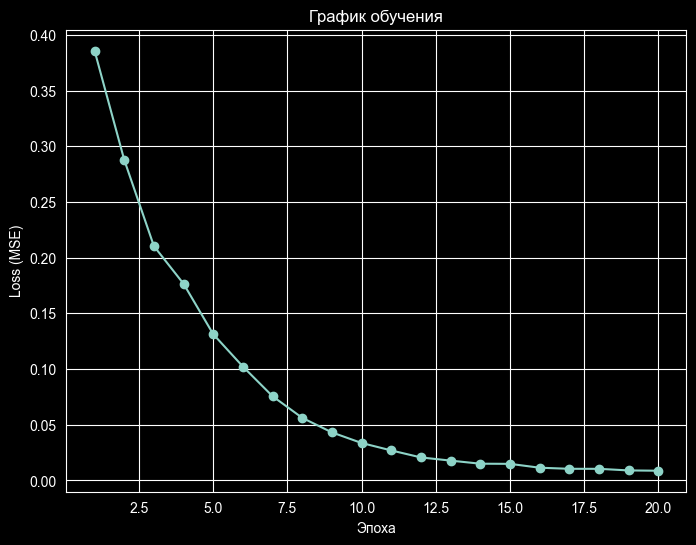

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.title('График обучения')
plt.grid(True)
plt.show()